# Questions
- Utiliser le fichier test que pour la meilleure méthode ou pour l'évaluation de chacune d'entre elles ?
- Faire phase de test sur notre meilleure méthode ?  

- Utiliser cv pour les baseslines ? (meme protocole d'évaluation que les méthdoes)
- "Analyse du déséquilibre éventuel" ?

# TO DO
- Méthode C
- Analyse des résultats
- README
- figure
- Analyse du désquilibre ?

Notes:

- Fait: Test sur toutes les méhtodes + baselines sur test et peut etre sur les "Questions à explorer"
- Pas besoin d'afficher les resultats sur l'apprentissage. il faut surtout sur le test.
- On a utilisé cv sur les baseslines pour garder le meme protocole.     
- On pourait justifier d'avoir utilisé cross validation, par ex car le dataset est petit.
- Analyse du déséquilibre éventuel entre les 2 proportions de classes sur train et test

A faire:
- Reutilise specificité lexicales sur méthode C




In [33]:
import pandas as pd

# Analyse
from collections import Counter
import re

# Specifité par classe
from collections import Counter
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords


# BaseLine
from sklearn.dummy import DummyClassifier

# Evaluation méthodes 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.base import clone
import numpy as np

# Evaluation méthodes (cv)
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate, cross_val_predict

# Méthodes
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Méthode B
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Méthode C
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix, hstack

# Plots
import os
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\33784\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
test = pd.read_csv("../data/test.csv")
train = pd.read_csv("../data/train.csv")

In [4]:
# TF-IDF ne peut prendre qu'un seul champ en entrée
# df["text"] = données concatenees par avec des espaces.

for df in (train, test):
    df["text"] = (
        df["titre"].fillna("") + " " +
        df["ingredients"].fillna("") + " " +
        df["recette"].fillna("")
    )



# Exploration des données

In [5]:
print("Exploration des données\n")

print("Nombre de documents par sous-ensemble:")
print("Train:", train.shape, "\nTest:", test.shape)

Exploration des données

Nombre de documents par sous-ensemble:
Train: (12473, 8) 
Test: (1388, 8)


In [6]:
train_counts = train["type"].value_counts()
test_counts = test["type"].value_counts()

train_pct = train["type"].value_counts(normalize=True) * 100
test_pct = test["type"].value_counts(normalize=True) * 100

comparaison = pd.DataFrame({
    "train_effectif": train_counts,
    "train_%": train_pct,
    "---": "",
    "test_effectif": test_counts,
    "test_%": test_pct
}).fillna(0)

print("\nComparaison de la répartition des classes :")
comparaison


Comparaison de la répartition des classes :


,train_effectif,train_%,---,test_effectif,test_%
type,,,,,
Plat principal,5802,46.516476,,644,46.397695
Dessert,3762,30.161148,,407,29.322767
Entrée,2909,23.322376,,337,24.279539


In [7]:
# On compte le nombre de mots et affiche les stats sur ces longueurs.

length_stats = pd.DataFrame({
    col: train[col].str.split().apply(len).describe()
    for col in ["ingredients", "recette", "text"]
}).T

print("\nStatistiques des longueurs (en nombre de mots) :")
length_stats


Statistiques des longueurs (en nombre de mots) :


,count,mean,std,min,25%,50%,75%,max
ingredients,12473.0,47.168444,21.263231,7.0,33.0,43.0,57.0,232.0
recette,12473.0,123.551431,67.825932,9.0,81.0,109.0,149.0,1334.0
text,12473.0,175.846949,81.010377,25.0,124.0,159.0,209.0,1450.0


- count = 12473 : 12 473 recettes
- mean = 175.85 : en moyenne, une ligne fait ~176 mots.
- std = 81.01 : l’écart-type (dispersion).
- min = 25 : la plus courte ligne a 25 mots.

### Spécificités lexicales par classe

In [8]:
french_stopwords = set(stopwords.words("french"))

def tokenize(text, strip_accents=False):
    """
    Tokenisation :
    - minuscule
    - suppression des élisions fréquentes : d', l', qu', ...
    - extraction des mots
    - suppression des stopwords français
    - suppression des tokens trop courts
    """
    if not isinstance(text, str):
        return []

    text = text.lower()

    # enlève les élisions fréquentes : d'asperge -> asperge, l'avocat -> avocat
    text = re.sub(r"\b(?:d|l|j|m|n|s|t|c|qu)'", "", text)

    # extrait les mots alphabétiques (avec accents et tirets)
    tokens = re.findall(r"[a-zàâçéèêëîïôûùüÿñæœ]+(?:-[a-zàâçéèêëîïôûùüÿñæœ]+)*", text)

    stopwords_set = french_stopwords

    # filtre stopwords + longueur minimale
    tokens = [
        tok for tok in tokens
        if len(tok) >= 3 and tok not in stopwords_set
    ]

    return tokens

In [9]:
def top_specific_words_by_class(df, text_col="text", label_col="type", top_n=15, min_freq=5):
    results = {}

    # tokens de tout le corpus
    all_tokens = df[text_col].fillna("").apply(tokenize)

    for classe in sorted(df[label_col].unique()):
        mask = df[label_col] == classe

        class_tokens = [tok for doc in all_tokens[mask] for tok in doc]
        other_tokens = [tok for doc in all_tokens[~mask] for tok in doc]

        class_counts = Counter(class_tokens)
        other_counts = Counter(other_tokens)

        total_class = sum(class_counts.values())
        total_other = sum(other_counts.values())

        scores = []
        vocab = set(class_counts.keys())

        for word in vocab:
            if class_counts[word] < min_freq:
                continue

            # fréquences relatives + lissage
            freq_class = (class_counts[word] + 1) / (total_class + 1)
            freq_other = (other_counts[word] + 1) / (total_other + 1)

            # ratio_specificite = P(mot | classe) / P(mot | hors_classe)
            ratio = freq_class / freq_other

            scores.append((word, class_counts[word], other_counts[word], ratio))

        # tri par ratio décroissant puis fréquence dans la classe
        scores = sorted(scores, key=lambda x: (x[3], x[1]), reverse=True)[:top_n]

        results[classe] = pd.DataFrame(
            scores,
            columns=["mot", "freq_classe", "freq_hors_classe", "ratio_specificite"]
        )

    return results

In [32]:
# Execution
specific_words = top_specific_words_by_class(
    train,
    text_col="text",
    label_col="type",
    top_n=20,
    min_freq=8
)

# Affichage
for classe, df_words in specific_words.items():
    print(f"\n=== {classe} ===")
    print(df_words.to_string(index=False))


=== Dessert ===
       mot  freq_classe  freq_hors_classe  ratio_specificite
   biscuit          313                 1         363.649754
   ganache           93                 0         217.726604
    pralin           84                 0         196.880440
  chocolat         4082                50         185.435487
pâtissière          156                 1         181.824877
  meringue          141                 1         164.453073
  biscuits          764                10         161.083996
frangipane           63                 0         148.239390
   génoise          186                 2         144.378989
 spéculoos          236                 3         137.237248
     glace         1346                22         135.651127
 speculoos           57                 0         134.341947
   glaçage          280                 4         130.172714
   brownie           55                 0         129.709466
   pépites          271                 4         126.003482
   vani

Pour chaque classe, nous avons extrait les mots les plus spécifiques en comparant leur fréquence relative dans la classe à leur fréquence relative dans le reste du corpus. Cette mesure de surreprésentation permet d’identifier les termes caractéristiques de chaque catégorie, au-delà des mots simplement fréquents dans l’ensemble des recettes.

### Fonction d'évaluation

In [11]:
X_train = train["text"]
y_train = train["type"]

X_test = test["text"]
y_test = test["type"]

In [12]:
random_state = 42
# cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

In [13]:
# micro-F1 : F1 globale en agrégeant toutes les classes (les classes fréquentes pèsent plus)
# macro-F1 : moyenne des F1 calculées séparément pour chaque classe (toutes les classes pèsent pareil)
# accuracy : pourcentage de prédictions correctes

# Fonction d'évaluation pour une méthode
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    final_model = clone(model) # pour etre sur que le modele ne connaissent rien
    final_model.fit(X_train, y_train) # apprentissage
    y_pred = final_model.predict(X_test) # test

    micro = f1_score(y_test, y_pred, average="micro")
    macro = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print("micro-F1 :", micro)
    print("macro-F1 :", macro)
    print("accuracy :", acc)

    print("\n=== Classification report ===")
    print(classification_report(y_test, y_pred, digits=3))

    labels = np.unique(y_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    print("\n=== Matrice de confusion ===")
    print(labels)
    print(cm)

    # pour le tableau de comparaison entre méthode
    return {
        "Méthode": name,
        "micro-F1": micro,
        "macro-F1": macro,
        "accuracy": acc
    }

In [14]:
# Avec cross validate pour ne pas utiliser le fichier de test.

def evaluate_model_cv(name, model, X, y, cv):
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring={
            "micro_f1": "f1_micro",
            "macro_f1": "f1_macro",
            "acc": "accuracy"
        }
    )

    micro = scores["test_micro_f1"].mean()
    macro = scores["test_macro_f1"].mean()
    acc = scores["test_acc"].mean()

    print(f"\n=== {name} ===")
    print("micro-F1 :", micro)
    print("macro-F1 :", macro)
    print("accuracy :", acc)

    y_pred = cross_val_predict(model, X, y, cv=cv)

    print("\n=== Classification report ===")
    print(classification_report(y, y_pred, digits=3))

    labels = sorted(y.unique())
    cm = confusion_matrix(y, y_pred, labels=labels)

    print("\n=== Matrice de confusion ===")
    print(labels)
    print(cm)

    return {
        "Méthode": name,
        "micro-F1": micro,
        "macro-F1": macro,
        "accuracy": acc
    }

In [15]:
# Pour l'analyse des résulats finales:
results = []

### Les titres seuls sont-ils discriminants ? 
### Les instructions seules suffisent-elles ?
### Certaines recettes semblent-elles ambiguës ?

In [16]:
X_titre = train["titre"].fillna("")
X_recette = train["recette"].fillna("")

On utilise le même pipeline TF-IDF + LinearSVC pour comparer titre seul, recette seule et texte complet de façon équitable. Ainsi, les différences de résultats viennent du champ utilisé, pas d’un changement de méthode.  
TF IDF: vecteur de mots pondérés seulon l'importance.  
LinearSVC: classifieur 

In [17]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

In [18]:
results_exploration = []

# On test avec cv sur le fichier train pour ne pas influencer les résulats lors du test final.
results_exploration.append(evaluate_model_cv("Titre seul", model, X_titre, y_train, cv))
results_exploration.append(evaluate_model_cv("Recette seule", model, X_recette, y_train, cv))
results_exploration.append(evaluate_model_cv("Texte complet", model, X_train, y_train, cv))


=== Titre seul ===
micro-F1 : 0.8232172444327308
macro-F1 : 0.8079391205435345
accuracy : 0.8232172444327308

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.919     0.926     0.923      3762
        Entrée      0.696     0.642     0.668      2909
Plat principal      0.820     0.847     0.833      5802

      accuracy                          0.823     12473
     macro avg      0.812     0.805     0.808     12473
  weighted avg      0.821     0.823     0.822     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[3483   93  186]
 [ 144 1869  896]
 [ 162  724 4916]]

=== Recette seule ===
micro-F1 : 0.8608197308811689
macro-F1 : 0.8452838843643683
accuracy : 0.8608197308811689

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.968     0.986     0.977      3762
        Entrée      0.740     0.657     0.696      2909
Plat principal      0.844 

In [19]:
results_exploration_df = pd.DataFrame(results_exploration)
results_exploration_df

,Méthode,micro-F1,macro-F1,accuracy
0,Titre seul,0.823217,0.807939,0.823217
1,Recette seule,0.860820,0.845284,0.860820
2,Texte complet,0.870440,0.857163,0.870440


##### Les titres seuls sont-ils discriminants ? 
Les titres seuls sont déjà assez discriminants, ce qui montre qu’ils contiennent souvent des indices lexicaux forts sur le type de recette. Mais ils ne suffisent pas toujours à bien distinguer les entrées des plats.  

##### Les instructions seules suffisent-elles ?
Les instructions permettent d’obtenir de bonnes performances, supérieures à celles du titre seul. Elles contiennent une information très utile pour la classification.  
Le texte complet reste meilleur, ce qui montre que les autres champs apportent une information complémentaire.

##### Certaines recettes semblent-elles ambiguës ?
Oui, les chiffres montrent que l’ambiguïté concerne surtout Entrée et Plat principal. Avec le texte complet, 865 entrées sont classées comme plats, et 643 plats comme entrées.  
À l’inverse, les desserts sont beaucoup plus faciles à reconnaître (F1 = 0.986, contre 0.717 pour Entrée).

# Baseline

In [20]:
# Baseline Aleatoire
rand_baseline = DummyClassifier(strategy="uniform", random_state=random_state)

results_random = evaluate_model(
    "Baseline aléatoire",
    rand_baseline,
    X_train, y_train,
    X_test, y_test
)

results.append(results_random)


=== Baseline aléatoire ===
micro-F1 : 0.31556195965417866
macro-F1 : 0.30925500105011516
accuracy : 0.31556195965417866

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.265     0.312     0.287       407
        Entrée      0.235     0.315     0.269       337
Plat principal      0.449     0.318     0.372       644

      accuracy                          0.316      1388
     macro avg      0.316     0.315     0.309      1388
  weighted avg      0.343     0.316     0.322      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[127 135 145]
 [124 106 107]
 [228 211 205]]


In [21]:
# Baseline 2 : Classe majoritaire
# Le but est de faire un modele bete qui trouve tjrs en sortie la classe majoritaire (Plat principal) afin d'avoir une baseline.

# faux modèle qui va apprndre la classe la plus fréquente
majoritaire_baseline = DummyClassifier(strategy="most_frequent")

results_majoriatire = evaluate_model(
    "Baseline majoritaire",
    majoritaire_baseline,
    X_train, y_train,
    X_test, y_test
)

results.append(results_majoriatire)


=== Baseline majoritaire ===
micro-F1 : 0.46397694524495675
macro-F1 : 0.21128608923884515
accuracy : 0.46397694524495675

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.000     0.000     0.000       407
        Entrée      0.000     0.000     0.000       337
Plat principal      0.464     1.000     0.634       644

      accuracy                          0.464      1388
     macro avg      0.155     0.333     0.211      1388
  weighted avg      0.215     0.464     0.294      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[  0   0 407]
 [  0   0 337]
 [  0   0 644]]


c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

# Evalutation

## Méthode A: TF-IDF + Naive Bayes

In [22]:
# Méthode A:

# Représentation sac de mots : TF-IDF
# Unités : unigrammes (ngram_range=(1,1))
# Classifieur : Naive Bayes (MultinomialNB)

runA = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 1),   # unigrammes
        min_df=2              # ignore mots trop rares
    )),
    ("clf", MultinomialNB(alpha=1.0))  # alpha = lissage de Laplace (testable)
])

In [23]:
results_A = evaluate_model(
    "Run A (TF-IDF unigrammes + MultinomialNB)",
    runA,
    X_train, y_train,
    X_test, y_test
)
results.append(results_A)


=== Run A (TF-IDF unigrammes + MultinomialNB) ===
micro-F1 : 0.8054755043227666
macro-F1 : 0.7322642102241345
accuracy : 0.8054755043227666

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.960     0.998     0.978       407
        Entrée      0.884     0.249     0.389       337
Plat principal      0.722     0.975     0.830       644

      accuracy                          0.805      1388
     macro avg      0.855     0.741     0.732      1388
  weighted avg      0.831     0.805     0.766      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[406   0   1]
 [ 12  84 241]
 [  5  11 628]]


## Méthode B: Logistic Regression + TF-IDF + n-grams (1–2)

In [24]:
runB_LogisticRegression = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=random_state
    ))
])

In [25]:
results_B_LogisticRegression = evaluate_model(
    "Run B (TF-IDF n-grams (1,2) + Logistic Regression)",
    runB_LogisticRegression,
    X_train, y_train,
    X_test, y_test
)

results.append(results_B_LogisticRegression)


=== Run B (TF-IDF n-grams (1,2) + Logistic Regression) ===
micro-F1 : 0.8717579250720461
macro-F1 : 0.8593281789236973
accuracy : 0.8717579250720461

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.978     0.993     0.985       407
        Entrée      0.791     0.662     0.721       337
Plat principal      0.841     0.905     0.872       644

      accuracy                          0.872      1388
     macro avg      0.870     0.853     0.859      1388
  weighted avg      0.869     0.872     0.869      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[404   1   2]
 [  6 223 108]
 [  3  58 583]]


## Méthode B: SVM + TF-IDF + n-grams (1–2)

In [26]:
runB_SVM = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LinearSVC())
])

In [27]:
results_B_SVM = evaluate_model(
    "Run B (TF-IDF uni+bi-grammes + LinearSVC)",
    runB_SVM,
    X_train, y_train,
    X_test, y_test
)
results.append(results_B_SVM)


=== Run B (TF-IDF uni+bi-grammes + LinearSVC) ===
micro-F1 : 0.877521613832853
macro-F1 : 0.8680793986836911
accuracy : 0.877521613832853

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.983     0.998     0.990       407
        Entrée      0.780     0.703     0.739       337
Plat principal      0.857     0.893     0.875       644

      accuracy                          0.878      1388
     macro avg      0.873     0.865     0.868      1388
  weighted avg      0.875     0.878     0.876      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[406   1   0]
 [  4 237  96]
 [  3  66 575]]


## Méthode C: Modèle enrichi

Ajout de features linguistiques :  
- longueur
- présence de termes sucrés/salés
- nombre d’ingrédients
- Comparaison avec version sans enrichissement

In [34]:
dessert_words = set(specific_words["Dessert"]["mot"].str.lower())
entree_words = set(specific_words["Entrée"]["mot"].str.lower())
plat_words = set(specific_words["Plat principal"]["mot"].str.lower())

In [35]:
import pandas as pd
from scipy.sparse import csr_matrix

def specific_words_features(df):
    texts = df["text"].fillna("").str.lower()

    feats = pd.DataFrame({
        "dessert_score": texts.apply(lambda txt: sum(1 for w in dessert_words if w in txt)),
        "entree_score": texts.apply(lambda txt: sum(1 for w in entree_words if w in txt)),
        "plat_score": texts.apply(lambda txt: sum(1 for w in plat_words if w in txt)),
    })

    feats["has_dessert_word"] = (feats["dessert_score"] > 0).astype(int)
    feats["has_entree_word"] = (feats["entree_score"] > 0).astype(int)
    feats["has_plat_word"] = (feats["plat_score"] > 0).astype(int)

    return csr_matrix(feats.values)

In [36]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

text_selector = FunctionTransformer(lambda df: df["text"], validate=False)
manual_features = FunctionTransformer(specific_words_features, validate=False)

runC_SVM = Pipeline([
    ("features", FeatureUnion([
        ("tfidf", Pipeline([
            ("select_text", text_selector),
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2
            ))
        ])),
        ("specific_words", manual_features)
    ])),
    ("clf", LinearSVC())
])

In [37]:
results_C_SVM = evaluate_model(
    "Run C (TF-IDF uni+bi-grammes + mots spécifiques + LinearSVC)",
    runC_SVM,
    X_train, y_train,
    X_test, y_test
)

results.append(results_C_SVM)

KeyError: 'text'

# Analyse

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Méthode,micro-F1,macro-F1,accuracy
0,Baseline aléatoire,0.315562,0.309255,0.315562
1,Baseline majoritaire,0.463977,0.211286,0.463977
2,Run A (TF-IDF unigrammes + MultinomialNB),0.805476,0.732264,0.805476
3,"Run B (TF-IDF n-grams (1,2) + Logistic Regress...",0.871758,0.859328,0.871758
4,Run B (TF-IDF uni+bi-grammes + LinearSVC),0.877522,0.868079,0.877522


In [ ]:
os.makedirs("../plots", exist_ok=True)

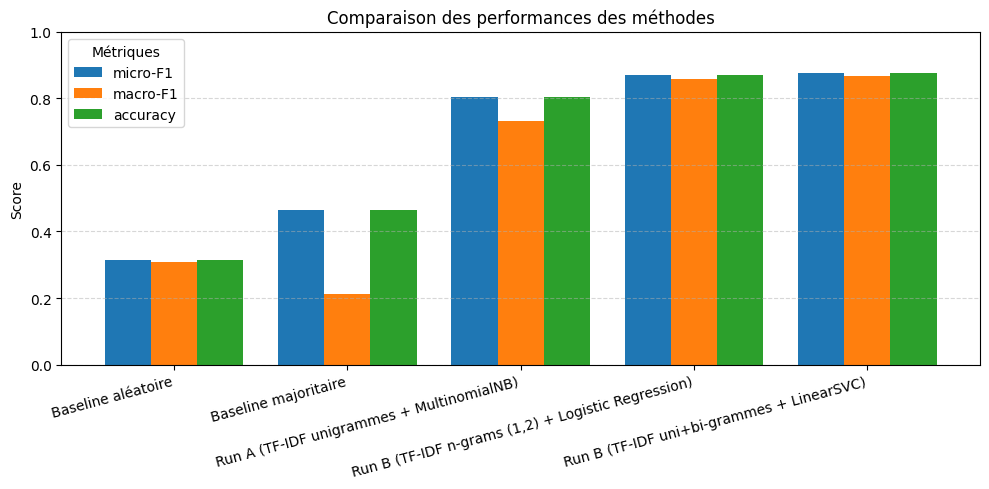

In [ ]:
plot_df = results_df.set_index("Méthode")

ax = plot_df.plot(kind="bar", figsize=(10, 5), width=0.8)

plt.title("Comparaison des performances des méthodes")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Métriques")
plt.tight_layout()

plt.savefig("../plots/comparaison_methodes.png", dpi=300, bbox_inches="tight")
plt.show()

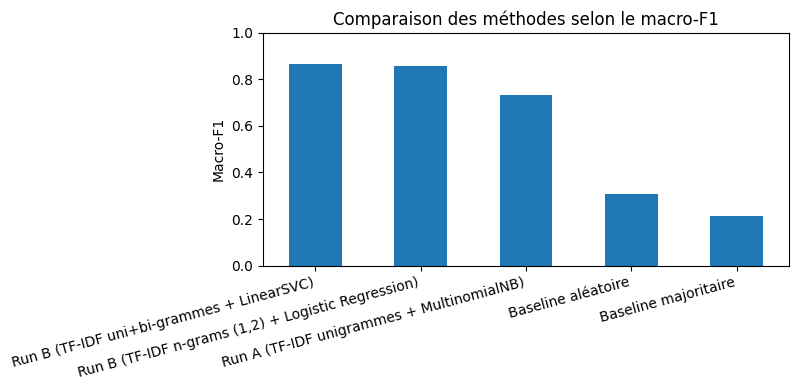

In [ ]:
results_df.sort_values("macro-F1", ascending=False).plot(
    x="Méthode",
    y="macro-F1",
    kind="bar",
    figsize=(8, 4),
    legend=False
)

plt.title("Comparaison des méthodes selon le macro-F1")
plt.ylabel("Macro-F1")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

plt.savefig("../plots/comparaison_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()